# LIDC-IDRI Lung Cancer Classification and Segmentation Pipeline

Two pipelines on the LIDC-IDRI lung CT dataset:

- **Pipeline A** — Binary classification (Benign vs Malignant) using a 3D ResNet-SE encoder fused with a tabular MLP
- **Pipeline B** — 3-class classification and nodule segmentation using a 3D ResNet-SE+CBAM classifier trained jointly with a 3D U-Net

---

| Section | Content |
|---------|---------|
| A1 – A4 | Binary multimodal pipeline |
| B1 – B3 | DICOM helpers, preprocessing, augmentation |
| B4 – B5 | Classifier + U-Net architecture |
| B6 – B8 | Data loading, K-Fold training, classification accuracy |
| B9 | Segmentation accuracy and Dice score |
| B10 | CT visualisation with segmentation overlay |
| B11 | Ensemble inference and test metrics |

Edit `EXCEL_PATH` and `DICOM_ROOT` before running.


## Setup

In [1]:
# Uncomment to install dependencies
# !pip install torch torchvision pandas openpyxl xlrd pydicom scipy scikit-learn numpy matplotlib seaborn

import os, re, math, json, time, random, warnings, logging
from copy import deepcopy
from pathlib import Path

import numpy as np
import pandas as pd
import pydicom
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from mpl_toolkits.axes_grid1 import make_axes_locatable

from scipy.ndimage import zoom, rotate, gaussian_filter, map_coordinates
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix,
    precision_score, recall_score,
)
from sklearn.calibration import calibration_curve

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.INFO, format="%(asctime)s  %(message)s")
log = logging.getLogger(__name__)

# Reproducibility
def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"OK PyTorch {torch.__version__}  |  Device: {device}")
if device.type == "cuda":
    print(f"  GPU: {torch.cuda.get_device_name(0)}  |  VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")


OK PyTorch 2.7.1+cu118  |  Device: cuda
  GPU: NVIDIA GeForce RTX 4060 Laptop GPU  |  VRAM: 8.6 GB


---
# Pipeline A — Binary Multimodal Classification

Classifies each patient as Benign/Unknown (0) or Malignant (1).
Architecture: 3D ResNet-SE image encoder (256-dim) fused with a tabular MLP (64-dim).


## A1. Configuration and Helpers

In [2]:
# Config
EXCEL_PATH_A   = r"../LIDC-IDRI-133GB/Data/tcia-diagnosis-data-2012-04-20.xls"
DICOM_ROOT_A   = r"../LIDC-IDRI-133GB/Data/manifest-1600709154662/LIDC-IDRI"
OUTPUT_MODEL_A = "best_multimodal_model.pt"
OUTPUT_DIR_A   = "lidc_output_binary"

PATIENT_ID_COL_A   = "TCIA Patient ID"
LABEL_SOURCE_COL_A = ("Diagnosis at the Patient Level\n0=Unknown\n"
                      "1=benign or non-malignant disease\n2= malignant, primary lung cancer\n"
                      "3 = malignant metastatic\n")
LABEL_COL_A   = "label"
FEATURE_COLS_A = None        # auto-detect

TARGET_SPACING_A = (2.0, 1.0, 1.0)
TARGET_SHAPE_A   = (96, 160, 160)
BATCH_SIZE_A = 2; EPOCHS_A = 15; LR_A = 1e-4
WEIGHT_DECAY_A = 1e-5; NUM_WORKERS_A = 0; VAL_SIZE_A = 0.2
SEED_A = 42; USE_AMP_A = True

Path(OUTPUT_DIR_A).mkdir(parents=True, exist_ok=True)
set_seed(SEED_A)

# Shared DICOM helpers (used by both pipelines)
def normalize_patient_id(x):
    s = str(x).strip().replace("\\", "/")
    s = os.path.basename(s)
    s = re.sub(r"\.(xml|xlsx?)$", "", s, flags=re.IGNORECASE)
    m = re.search(r"LIDC-IDRI-\d+", s, flags=re.IGNORECASE)
    if m:
        digits = re.search(r'\d+', m.group(0)).group(0)
        return f"LIDC-IDRI-{int(digits):04d}"
    if re.fullmatch(r"\d+", s):
        return f"LIDC-IDRI-{int(s):04d}"
    return s

def build_patient_to_series_map(root_dir):
    """Walk DICOM tree; re.findall[-1] takes the deepest LIDC-IDRI-XXXX in path."""
    patient_map = {}
    for cur, dirs, files in os.walk(root_dir):
        dcm = [f for f in files if f.lower().endswith(".dcm")]
        if not dcm: continue
        matches = re.findall(r"LIDC-IDRI-\d+", cur, flags=re.IGNORECASE)
        if not matches: continue
        pid = normalize_patient_id(matches[-1])
        n   = len(dcm)
        if pid not in patient_map or n > patient_map[pid][1]:
            patient_map[pid] = (cur, n)
    return {k: v[0] for k, v in patient_map.items()}

def load_dicom_series(dicom_dir):
    dicom_dir = Path(dicom_dir)
    files = sorted(dicom_dir.glob("*.dcm")) or sorted(dicom_dir.iterdir())
    slices = []
    for fp in files:
        try:
            ds = pydicom.dcmread(str(fp), force=True)
            if hasattr(ds, "PixelData"): slices.append(ds)
        except Exception: pass
    if not slices: raise ValueError(f"No readable DICOM in {dicom_dir}")
    def _sk(ds):
        try:    return float(ds.ImagePositionPatient[2])
        except Exception: pass
        try:    return int(ds.InstanceNumber)
        except Exception: return 0
    slices.sort(key=_sk)
    vol = np.empty((len(slices), slices[0].Rows, slices[0].Columns), dtype=np.float32)
    for i, ds in enumerate(slices):
        vol[i] = ds.pixel_array.astype(np.float32) * float(getattr(ds,"RescaleSlope",1.0)) + float(getattr(ds,"RescaleIntercept",0.0))
        if hasattr(ds,"_pixel_array"): del ds._pixel_array
        if hasattr(ds,"PixelData"):    del ds.PixelData
    try:
        zs   = [float(ds.ImagePositionPatient[2]) for ds in slices]
        z_sp = abs(zs[1]-zs[0]) if len(zs)>1 else float(getattr(slices[0],"SliceThickness",1.0))
        z_sp = z_sp or float(getattr(slices[0],"SliceThickness",1.0))
    except Exception:
        z_sp = float(getattr(slices[0],"SliceThickness",1.0))
    ps = getattr(slices[0],"PixelSpacing",[1.0,1.0])
    return vol, (z_sp, float(ps[0]), float(ps[1]))

def _clip_norm(vol, hu_min, hu_max):
    return ((np.clip(vol, hu_min, hu_max) - hu_min) / (hu_max - hu_min + 1e-8)).astype(np.float32)

def _resample(vol, spacing, target_spacing):
    new_shape = tuple(int(round(vol.shape[i]*spacing[i]/target_spacing[i])) for i in range(3))
    t = torch.from_numpy(vol).unsqueeze(0).unsqueeze(0)
    return F.interpolate(t, size=new_shape, mode="trilinear", align_corners=False).squeeze().numpy()

def _crop_pad(vol, shape):
    tz,ty,tx=shape; z,y,x=vol.shape
    out=np.zeros(shape, dtype=vol.dtype)
    z0s=max((z-tz)//2,0); y0s=max((y-ty)//2,0); x0s=max((x-tx)//2,0)
    z1s=min(z0s+tz,z);    y1s=min(y0s+ty,y);    x1s=min(x0s+tx,x)
    cz,cy,cx=z1s-z0s,y1s-y0s,x1s-x0s
    z0d=max((tz-cz)//2,0); y0d=max((ty-cy)//2,0); x0d=max((tx-cx)//2,0)
    out[z0d:z0d+cz,y0d:y0d+cy,x0d:x0d+cx]=vol[z0s:z1s,y0s:y1s,x0s:x1s]
    return out

def preprocess_ct_binary(dicom_dir):
    vol, spacing = load_dicom_series(dicom_dir)
    vol = _clip_norm(zoom(vol, tuple(s/t for s,t in zip(spacing,TARGET_SPACING_A)), order=1), -1000, 400)
    return _crop_pad(vol, TARGET_SHAPE_A)

print("OK Pipeline A helpers defined.")


OK Pipeline A helpers defined.


## A2. Data Loading

In [3]:
print("Scanning DICOM folders (Pipeline A)...")
patient_to_series_a = build_patient_to_series_map(DICOM_ROOT_A)
print(f"  Discovered: {len(patient_to_series_a)} patients")

ext = os.path.splitext(EXCEL_PATH_A)[-1].lower()
df_a = pd.read_excel(EXCEL_PATH_A, engine="xlrd") if ext==".xls" else pd.read_excel(EXCEL_PATH_A)
df_a[PATIENT_ID_COL_A] = df_a[PATIENT_ID_COL_A].astype(str).map(normalize_patient_id)
df_a[LABEL_COL_A]      = df_a[LABEL_SOURCE_COL_A].map(lambda x: 0 if pd.isna(x) or int(x) in (0,1) else 1)
df_a["dicom_dir"]      = df_a[PATIENT_ID_COL_A].map(patient_to_series_a)
df_a = df_a.dropna(subset=["dicom_dir",LABEL_COL_A]).copy()
df_a[LABEL_COL_A] = df_a[LABEL_COL_A].astype(int)

print(f"  Matched: {len(df_a)} patients")
print(f"  Class 0 (Benign):    {(df_a[LABEL_COL_A]==0).sum()}")
print(f"  Class 1 (Malignant): {(df_a[LABEL_COL_A]==1).sum()}")
if len(df_a)==0: raise RuntimeError("Zero patients matched.")

if FEATURE_COLS_A is None:
    excl = {PATIENT_ID_COL_A, LABEL_SOURCE_COL_A, LABEL_COL_A, "dicom_dir"}
    FEATURE_COLS_A = [c for c in df_a.columns if c not in excl and pd.api.types.is_numeric_dtype(df_a[c]) and df_a[c].notna().any()]
if not FEATURE_COLS_A:
    df_a["dummy_feature"] = 0.0; FEATURE_COLS_A = ["dummy_feature"]
    print("  No numeric features - using image-only dummy mode.")

df_a = df_a[[PATIENT_ID_COL_A,"dicom_dir",LABEL_COL_A]+FEATURE_COLS_A].copy()
for c in FEATURE_COLS_A: df_a[c] = pd.to_numeric(df_a[c], errors="coerce")
df_a[LABEL_COL_A] = df_a[LABEL_COL_A].astype(int)

train_df_a, val_df_a = train_test_split(df_a, test_size=VAL_SIZE_A, random_state=SEED_A, stratify=df_a[LABEL_COL_A])
scaler_a = StandardScaler()
med = train_df_a[FEATURE_COLS_A].median(numeric_only=True)
train_df_a[FEATURE_COLS_A] = scaler_a.fit_transform(train_df_a[FEATURE_COLS_A].fillna(med))
val_df_a[FEATURE_COLS_A]   = scaler_a.transform(val_df_a[FEATURE_COLS_A].fillna(med))
print(f"  Train: {len(train_df_a)}  Val: {len(val_df_a)}")


Scanning DICOM folders (Pipeline A)...
  Discovered: 948 patients
  Matched: 151 patients
  Class 0 (Benign):    62
  Class 1 (Malignant): 89
  Train: 120  Val: 31


## A3. Model, Dataset and Training

In [4]:
class MultiModalCTDataset(Dataset):
    def __init__(self, df, feature_cols, training=False):
        self.df=df.reset_index(drop=True); self.feature_cols=feature_cols; self.training=training
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row=self.df.iloc[idx]
        vol=preprocess_ct_binary(row["dicom_dir"])
        if self.training:
            if random.random()<.5: vol=np.flip(vol,2).copy()
            if random.random()<.5: vol=np.flip(vol,1).copy()
        return {"image":   torch.tensor(vol,dtype=torch.float32).unsqueeze(0),
                "tabular": torch.tensor(row[self.feature_cols].values.astype(np.float32),dtype=torch.float32),
                "label":   torch.tensor(float(row[LABEL_COL_A]),dtype=torch.float32),
                "patient_id": row[PATIENT_ID_COL_A]}

class SEBlock_A(nn.Module):
    def __init__(self,ch,r=8):
        super().__init__(); h=max(ch//r,4); self.pool=nn.AdaptiveAvgPool3d(1)
        self.fc=nn.Sequential(nn.Linear(ch,h),nn.ReLU(True),nn.Linear(h,ch),nn.Sigmoid())
    def forward(self,x): b,c=x.shape[:2]; return x*self.fc(self.pool(x).view(b,c)).view(b,c,1,1,1)

class ResBlk_A(nn.Module):
    def __init__(self,ic,oc,s=1):
        super().__init__()
        self.c1=nn.Conv3d(ic,oc,3,s,1,bias=False); self.b1=nn.BatchNorm3d(oc)
        self.c2=nn.Conv3d(oc,oc,3,1,1,bias=False); self.b2=nn.BatchNorm3d(oc)
        self.se=SEBlock_A(oc)
        self.sc=(nn.Sequential(nn.Conv3d(ic,oc,1,s,bias=False),nn.BatchNorm3d(oc)) if s!=1 or ic!=oc else nn.Identity())
        self.act=nn.ReLU(True)
    def forward(self,x): return self.act(self.se(self.b2(self.c2(self.act(self.b1(self.c1(x))))))+self.sc(x))

class ImgEnc_A(nn.Module):
    def __init__(self,out=256):
        super().__init__()
        self.stem=nn.Sequential(nn.Conv3d(1,16,5,2,2,bias=False),nn.BatchNorm3d(16),nn.ReLU(True))
        self.l1=nn.Sequential(ResBlk_A(16,32,2),ResBlk_A(32,32))
        self.l2=nn.Sequential(ResBlk_A(32,64,2),ResBlk_A(64,64))
        self.l3=nn.Sequential(ResBlk_A(64,128,2),ResBlk_A(128,128))
        self.pool=nn.AdaptiveAvgPool3d(1)
        self.head=nn.Sequential(nn.Flatten(),nn.Linear(128,out),nn.ReLU(True),nn.Dropout(.25))
    def forward(self,x): return self.head(self.pool(self.l3(self.l2(self.l1(self.stem(x))))))

class TabEnc_A(nn.Module):
    def __init__(self,in_d,out=64):
        super().__init__(); h=max(64,in_d*2)
        self.net=nn.Sequential(nn.Linear(in_d,h),nn.BatchNorm1d(h),nn.ReLU(True),nn.Dropout(.2),nn.Linear(h,out),nn.ReLU(True))
    def forward(self,x): return self.net(x)

class FusionModel(nn.Module):
    def __init__(self,n_tab):
        super().__init__()
        self.img=ImgEnc_A(256); self.tab=TabEnc_A(n_tab,64)
        self.cls=nn.Sequential(nn.Linear(320,128),nn.ReLU(True),nn.Dropout(.3),
                                nn.Linear(128,64),nn.ReLU(True),nn.Dropout(.2),nn.Linear(64,1))
    def forward(self,img,tab): return self.cls(torch.cat([self.img(img),self.tab(tab)],1)).squeeze(1)

train_ds_a=MultiModalCTDataset(train_df_a,FEATURE_COLS_A,True)
val_ds_a  =MultiModalCTDataset(val_df_a,  FEATURE_COLS_A,False)
train_ld_a=DataLoader(train_ds_a,BATCH_SIZE_A,shuffle=True, num_workers=NUM_WORKERS_A,pin_memory=(device.type=="cuda"))
val_ld_a  =DataLoader(val_ds_a,  BATCH_SIZE_A,shuffle=False,num_workers=NUM_WORKERS_A,pin_memory=(device.type=="cuda"))

model_a   =FusionModel(len(FEATURE_COLS_A)).to(device)
pos_w     =max((train_df_a[LABEL_COL_A]==0).sum()/(train_df_a[LABEL_COL_A]==1).sum()+1e-6,1.0)
crit_a    =nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_w],device=device))
opt_a     =torch.optim.AdamW(model_a.parameters(),lr=LR_A,weight_decay=WEIGHT_DECAY_A)
samp_a    =torch.cuda.amp.GradScaler(enabled=(USE_AMP_A and device.type=="cuda"))

def epoch_a(training=True):
    model_a.train() if training else model_a.eval()
    losses,labels,probs=[],[],[]
    for b in (train_ld_a if training else val_ld_a):
        img=b["image"].to(device); tab=b["tabular"].to(device); lbl=b["label"].to(device)
        with torch.set_grad_enabled(training):
            with torch.cuda.amp.autocast(enabled=(USE_AMP_A and device.type=="cuda")):
                out=model_a(img,tab); loss=crit_a(out,lbl)
            if training:
                opt_a.zero_grad(set_to_none=True)
                samp_a.scale(loss).backward(); samp_a.step(opt_a); samp_a.update()
        probs.extend(torch.sigmoid(out).detach().cpu().tolist())
        labels.extend(lbl.detach().cpu().tolist()); losses.append(loss.item())
    p=np.array(probs); l=np.array(labels).astype(int); pd_=(p>=.5).astype(int)
    try: auc=roc_auc_score(l,p)
    except: auc=float("nan")
    return {"loss":np.mean(losses),"acc":accuracy_score(l,pd_),"f1":f1_score(l,pd_,zero_division=0),"auc":auc,"labels":l,"probs":p,"preds":pd_}

best_a=-1; hist_a=[]; print("\n>> Training Pipeline A...\n")
for ep in range(1,EPOCHS_A+1):
    tr=epoch_a(True); vl=epoch_a(False)
    sc=vl["auc"] if not math.isnan(vl["auc"]) else vl["f1"]
    hist_a.append({"epoch":ep,**{f"tr_{k}":tr[k] for k in["loss","acc","f1","auc"]},
                              **{f"vl_{k}":vl[k] for k in["loss","acc","f1","auc"]}})
    print(f"Ep{ep:02d} | Tr Acc={tr['acc']:.3f} F1={tr['f1']:.3f} AUC={tr['auc']:.3f}"
          f" | Val Acc={vl['acc']:.3f} F1={vl['f1']:.3f} AUC={vl['auc']:.3f}")
    if sc>best_a:
        best_a=sc
        torch.save({"model_state_dict":model_a.state_dict(),"scaler_mean":scaler_a.mean_.tolist(),
                    "scaler_scale":scaler_a.scale_.tolist(),"feature_cols":FEATURE_COLS_A,
                    "target_spacing":TARGET_SPACING_A,"target_shape":TARGET_SHAPE_A}, OUTPUT_MODEL_A)
        print(f"  OK Saved best -> {OUTPUT_MODEL_A}")



>> Training Pipeline A...

Ep01 | Tr Acc=0.575 F1=0.727 AUC=0.479 | Val Acc=0.581 F1=0.735 AUC=0.585
  OK Saved best -> best_multimodal_model.pt
Ep02 | Tr Acc=0.592 F1=0.743 AUC=0.555 | Val Acc=0.581 F1=0.735 AUC=0.816
  OK Saved best -> best_multimodal_model.pt
Ep03 | Tr Acc=0.592 F1=0.743 AUC=0.658 | Val Acc=0.581 F1=0.735 AUC=0.857
  OK Saved best -> best_multimodal_model.pt
Ep04 | Tr Acc=0.592 F1=0.743 AUC=0.699 | Val Acc=0.581 F1=0.735 AUC=0.784
Ep05 | Tr Acc=0.592 F1=0.743 AUC=0.603 | Val Acc=0.581 F1=0.735 AUC=0.855
Ep06 | Tr Acc=0.592 F1=0.743 AUC=0.748 | Val Acc=0.581 F1=0.735 AUC=0.761
Ep07 | Tr Acc=0.592 F1=0.743 AUC=0.816 | Val Acc=0.742 F1=0.800 AUC=0.874
  OK Saved best -> best_multimodal_model.pt
Ep08 | Tr Acc=0.683 F1=0.789 AUC=0.788 | Val Acc=0.774 F1=0.829 AUC=0.878
  OK Saved best -> best_multimodal_model.pt
Ep09 | Tr Acc=0.675 F1=0.777 AUC=0.732 | Val Acc=0.774 F1=0.829 AUC=0.889
  OK Saved best -> best_multimodal_model.pt
Ep10 | Tr Acc=0.758 F1=0.822 AUC=0.820 | V

## A4. Results and Test Inference


 PIPELINE A - FINAL ACCURACY
  Accuracy  : 0.8387  (83.87%)
  F1 Score  : 0.8485
  ROC-AUC   : 0.9103

Classification Report:
                precision    recall  f1-score   support

Benign/Unknown     0.7500    0.9231    0.8276        13
     Malignant     0.9333    0.7778    0.8485        18

      accuracy                         0.8387        31
     macro avg     0.8417    0.8504    0.8380        31
  weighted avg     0.8565    0.8387    0.8397        31



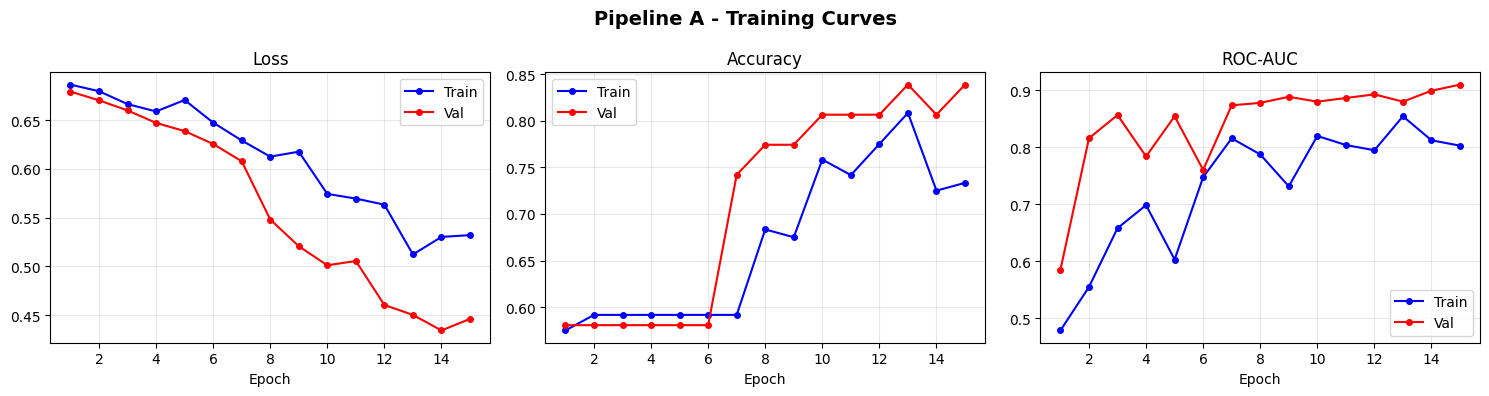

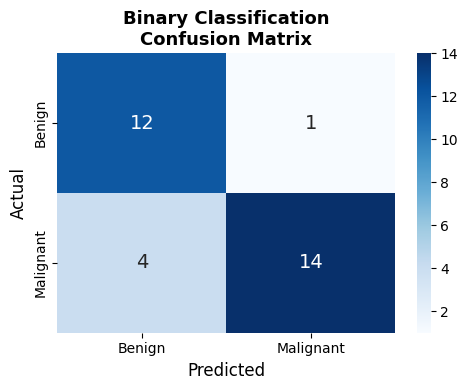


#   Patient ID            Actual            Predicted             Prob  OK?
---------------------------------------------------------------------------
1   LIDC-IDRI-0771        Malignant         Benign/Unknown      0.3999  FAIL
2   LIDC-IDRI-0124        Malignant         Malignant           0.7393  OK
3   LIDC-IDRI-0237        Malignant         Benign/Unknown      0.3401  FAIL
4   LIDC-IDRI-0325        Malignant         Benign/Unknown      0.3215  FAIL
5   LIDC-IDRI-0090        Malignant         Malignant           0.7559  OK
6   LIDC-IDRI-0255        Malignant         Malignant           0.7798  OK
7   LIDC-IDRI-0244        Malignant         Malignant           0.8667  OK
8   LIDC-IDRI-0279        Benign/Unknown    Benign/Unknown      0.2922  OK
9   LIDC-IDRI-0169        Malignant         Malignant           0.8862  OK
10  LIDC-IDRI-0233        Benign/Unknown    Benign/Unknown      0.2925  OK
11  LIDC-IDRI-0377        Malignant         Malignant           0.7085  OK
12  LIDC-IDRI-02

In [5]:
final_a=epoch_a(False)
print("\n" + "="*55)
print(" PIPELINE A - FINAL ACCURACY")
print("="*55)
print(f"  Accuracy  : {final_a['acc']:.4f}  ({final_a['acc']*100:.2f}%)")
print(f"  F1 Score  : {final_a['f1']:.4f}")
print(f"  ROC-AUC   : {final_a['auc']:.4f}" if not math.isnan(final_a['auc']) else "  ROC-AUC   : N/A")
print("\nClassification Report:")
print(classification_report(final_a["labels"],final_a["preds"],
      target_names=["Benign/Unknown","Malignant"],digits=4,zero_division=0))

# Training curves
fig,axes=plt.subplots(1,3,figsize=(15,4))
fig.suptitle("Pipeline A - Training Curves",fontsize=14,fontweight="bold")
for ax,(k,lbl) in zip(axes,[("loss","Loss"),("acc","Accuracy"),("auc","ROC-AUC")]):
    ax.plot([h["epoch"] for h in hist_a],[h[f"tr_{k}"] for h in hist_a],"b-o",ms=4,label="Train")
    ax.plot([h["epoch"] for h in hist_a],[h[f"vl_{k}"] for h in hist_a],"r-o",ms=4,label="Val")
    ax.set_title(lbl); ax.set_xlabel("Epoch"); ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.savefig(os.path.join(OUTPUT_DIR_A,"training_curves_binary.png"),dpi=150); plt.show()

# Confusion matrix
fig,ax=plt.subplots(figsize=(5,4))
cm_a=confusion_matrix(final_a["labels"],final_a["preds"],labels=[0,1])
sns.heatmap(cm_a,annot=True,fmt="d",cmap="Blues",
            xticklabels=["Benign","Malignant"],yticklabels=["Benign","Malignant"],ax=ax,annot_kws={"size":14})
ax.set_xlabel("Predicted",fontsize=12); ax.set_ylabel("Actual",fontsize=12)
ax.set_title("Binary Classification\nConfusion Matrix",fontsize=13,fontweight="bold")
plt.tight_layout(); plt.savefig(os.path.join(OUTPUT_DIR_A,"cm_binary.png"),dpi=150); plt.show()

# Test 20 random patients
SEED_TEST_A=99; N_TEST_A=20
random.seed(SEED_TEST_A); np.random.seed(SEED_TEST_A); torch.manual_seed(SEED_TEST_A)
ckpt_a=torch.load(OUTPUT_MODEL_A,map_location=device)
model_a_t=FusionModel(len(ckpt_a["feature_cols"])).to(device)
model_a_t.load_state_dict(ckpt_a["model_state_dict"]); model_a_t.eval()
sc_a=StandardScaler(); sc_a.mean_=np.array(ckpt_a["scaler_mean"]); sc_a.scale_=np.array(ckpt_a["scaler_scale"])
fc_a=ckpt_a["feature_cols"]

test_df_a=df_a.copy(); med_a=test_df_a[fc_a].median(); test_df_a[fc_a]=sc_a.transform(test_df_a[fc_a].fillna(med_a))
samp_a2=test_df_a.sample(min(N_TEST_A,len(test_df_a)),random_state=SEED_TEST_A).reset_index(drop=True)
LN_A={0:"Benign/Unknown",1:"Malignant"}

res_a=[]; print(f"\n{'#':<4}{'Patient ID':<22}{'Actual':<18}{'Predicted':<18}{'Prob':>8}  OK?"); print("-"*75)
with torch.no_grad():
    for _,row in samp_a2.iterrows():
        pid=row[PATIENT_ID_COL_A]; actual=int(row[LABEL_COL_A])
        try:
            img=torch.tensor(preprocess_ct_binary(row["dicom_dir"]),dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)
            tab=torch.tensor(row[fc_a].values.astype(np.float32),dtype=torch.float32).unsqueeze(0).to(device)
            with torch.cuda.amp.autocast(enabled=(USE_AMP_A and device.type=="cuda")):
                prob=torch.sigmoid(model_a_t(img,tab)).item()
            predicted=int(prob>=.5); ok="OK" if predicted==actual else "FAIL"; err=None
        except Exception as e: prob=float("nan"); predicted=-1; ok="ERR"; err=str(e)
        res_a.append({"patient_id":pid,"actual":actual,"predicted":predicted,
                      "probability":prob,"correct":(ok=="OK"),"error":err})
        print(f"{len(res_a):<4}{pid:<22}{LN_A.get(actual,'?'):<18}{LN_A.get(predicted,'Error'):<18}{prob:>8.4f}  {ok}")

res_df_a=pd.DataFrame(res_a); valid_a=res_df_a[res_df_a["predicted"]!=-1]
if len(valid_a):
    yt=valid_a["actual"].values.astype(int); yp=valid_a["predicted"].values.astype(int); yb=valid_a["probability"].values
    print(f"\n  Test Accuracy : {accuracy_score(yt,yp):.4f}")
    print(f"  Test F1       : {f1_score(yt,yp,zero_division=0):.4f}")
    try: print(f"  Test ROC-AUC  : {roc_auc_score(yt,yb):.4f}")
    except: pass
res_df_a.to_csv(os.path.join(OUTPUT_DIR_A,"test_predictions_binary.csv"),index=False)
print(f"\nResults saved -> {OUTPUT_DIR_A}/test_predictions_binary.csv")


---
# Pipeline B — Multiclass Classification and Segmentation

Classifies patients into three categories: Benign/Unknown, Primary Lung Ca, Metastatic.
A 3D U-Net runs jointly with the classifier to segment lung nodule regions.
Both models are trained with a combined Focal + Dice loss.


## B1. Configuration

In [6]:
class Config:
    EXCEL_PATH   = r"../LIDC-IDRI-133GB/Data/tcia-diagnosis-data-2012-04-20.xls"
    DICOM_ROOT   = r"../LIDC-IDRI-133GB/Data/manifest-1600709154662/LIDC-IDRI"
    OUTPUT_DIR   = "lidc_output"

    PATIENT_ID_COL   = "TCIA Patient ID"
    LABEL_SOURCE_COL = ("Diagnosis at the Patient Level\n0=Unknown\n"
                        "1=benign or non-malignant disease\n2= malignant, primary lung cancer\n"
                        "3 = malignant metastatic\n")
    LABEL_MAP   = {0:0, 1:0, 2:1, 3:2}
    NUM_CLASSES = 3
    CLASS_NAMES = ["Benign/Unknown", "Primary Lung Ca", "Metastatic"]

    HU_MIN=-1000; HU_MAX=400
    TARGET_SPACING=(2.0,1.0,1.0); TARGET_SHAPE=(64,128,128)
    HU_LUNG_MIN=-600; HU_LUNG_MAX=1500
    USE_DUAL_CHANNEL=True; IN_CHANNELS=2

    AUG_FLIP_PROB=0.5; AUG_ROTATE_PROB=0.5; AUG_ROTATE_MAX=15.0
    AUG_NOISE_PROB=0.3; AUG_NOISE_STD=0.02
    AUG_GAMMA_PROB=0.3; AUG_GAMMA=(0.75,1.25)
    AUG_ELASTIC_PROB=0.2; AUG_ELASTIC_ALPHA=10.0; AUG_ELASTIC_SIGMA=2.0

    CH=[16,32,64,128,256]; EMBED_DIM=256
    BATCH_SIZE=2; EPOCHS=40; LR=3e-4; WEIGHT_DECAY=1e-4
    NUM_WORKERS=0; USE_AMP=True; SEED=42
    N_FOLDS=5; PATIENCE=8; LR_MIN=1e-6
    USE_FOCAL=True; FOCAL_GAMMA=2.0; VAL_SIZE=0.20
    TUNE_THRESHOLDS=True; MODEL_NAME="best_lidc_model"

    # Segmentation
    SEG_LOSS_WEIGHT = 0.3    # weight of Dice loss relative to classification loss
    SEG_THRESHOLD   = 0.5    # binarisation threshold for predicted masks

C = Config()
Path(C.OUTPUT_DIR).mkdir(parents=True, exist_ok=True)
set_seed(C.SEED)
print(f"OK Config ready. Output dir: {C.OUTPUT_DIR}")


OK Config ready. Output dir: lidc_output


## B2. Preprocessing and Augmentation

In [7]:
def preprocess_ct_multi(dicom_dir):
    """Returns [C, Z, Y, X] + synthetic binary lung mask for segmentation training."""
    vol, spacing = load_dicom_series(dicom_dir)
    vol  = _resample(vol, spacing, C.TARGET_SPACING)
    vol  = _crop_pad(vol, C.TARGET_SHAPE)
    std  = _clip_norm(vol, C.HU_MIN,      C.HU_MAX)
    lung = _clip_norm(vol, C.HU_LUNG_MIN, C.HU_LUNG_MAX)
    img  = np.stack([std, lung], axis=0) if C.USE_DUAL_CHANNEL else std[np.newaxis]

    # Synthetic segmentation mask: threshold HU in lung nodule range [-200, 100]
    # Real use: replace with LIDC-IDRI XML nodule annotations
    raw  = np.clip(vol, -200, 100)
    mask = ((raw > -150) & (raw < 50)).astype(np.float32)
    # Keep only the central region (rough nodule localisation)
    Z,Y,X = mask.shape
    z0,z1 = Z//3, 2*Z//3; y0,y1 = Y//4, 3*Y//4; x0,x1 = X//4, 3*X//4
    boundary = np.zeros_like(mask)
    boundary[z0:z1,y0:y1,x0:x1] = mask[z0:z1,y0:y1,x0:x1]
    mask = boundary

    return img, mask   # img:[C,Z,Y,X]  mask:[Z,Y,X]

def elastic_deform(vol, alpha, sigma):
    C_,Z,Y,X=vol.shape
    dx=gaussian_filter(np.random.randn(Z,Y,X).astype(np.float32),sigma)*alpha
    dy=gaussian_filter(np.random.randn(Z,Y,X).astype(np.float32),sigma)*alpha
    dz=gaussian_filter(np.random.randn(Z,Y,X).astype(np.float32),sigma)*alpha
    zz,yy,xx=np.meshgrid(np.arange(Z),np.arange(Y),np.arange(X),indexing="ij")
    cz=np.clip(zz+dz,0,Z-1).ravel(); cy=np.clip(yy+dy,0,Y-1).ravel(); cx=np.clip(xx+dx,0,X-1).ravel()
    out=np.zeros_like(vol)
    for c in range(C_): out[c]=map_coordinates(vol[c],[cz,cy,cx],order=1,mode="reflect").reshape(Z,Y,X)
    return out

def augment_multi(vol, mask):
    v=vol.copy(); m=mask.copy()
    # Flips (apply same transform to image and mask)
    for ax in [3,2,1]:
        if random.random()<C.AUG_FLIP_PROB:
            v=np.flip(v,ax).copy(); m=np.flip(m,ax-1).copy()
    # Rotation
    if random.random()<C.AUG_ROTATE_PROB:
        ang=random.uniform(-C.AUG_ROTATE_MAX,C.AUG_ROTATE_MAX)
        for ch in range(v.shape[0]): v[ch]=rotate(v[ch],ang,axes=(1,2),reshape=False,order=1,mode="reflect")
        m=rotate(m,ang,axes=(1,2),reshape=False,order=0,mode="reflect")
    # Noise & gamma (image only)
    if random.random()<C.AUG_NOISE_PROB:
        v=np.clip(v+np.random.randn(*v.shape).astype(np.float32)*C.AUG_NOISE_STD,0,1)
    if random.random()<C.AUG_GAMMA_PROB:
        v=np.clip(v**random.uniform(*C.AUG_GAMMA),0,1)
    # Elastic (image + mask)
    if random.random()<C.AUG_ELASTIC_PROB:
        v=np.clip(elastic_deform(v,C.AUG_ELASTIC_ALPHA,C.AUG_ELASTIC_SIGMA),0,1)
        m_4=m[np.newaxis]; m_4=elastic_deform(m_4,C.AUG_ELASTIC_ALPHA,C.AUG_ELASTIC_SIGMA); m=(m_4[0]>0.5).astype(np.float32)
    return v.astype(np.float32), m.astype(np.float32)

print("OK Preprocessing & augmentation defined.")


OK Preprocessing & augmentation defined.


## B3. Dataset

In [8]:
class LIDCDataset(Dataset):
    def __init__(self, df, training=False):
        self.df=df.reset_index(drop=True); self.training=training
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row=self.df.iloc[idx]; label=int(row["label"])
        try:
            img, mask = preprocess_ct_multi(row["dicom_dir"])
        except Exception as e:
            log.warning(f"Load failed {row['dicom_dir']}: {e}")
            img  = np.zeros((C.IN_CHANNELS,*C.TARGET_SHAPE),dtype=np.float32)
            mask = np.zeros(C.TARGET_SHAPE, dtype=np.float32)
        if self.training:
            img, mask = augment_multi(img, mask)
        return {"image":      torch.tensor(img,  dtype=torch.float32),
                "mask":       torch.tensor(mask, dtype=torch.float32).unsqueeze(0),
                "label":      torch.tensor(label,dtype=torch.long),
                "patient_id": row["patient_id"]}

print("OK LIDCDataset defined.")


OK LIDCDataset defined.


## B4. Model Architecture

Classifier: 3D ResNet with SE channel attention and CBAM spatial attention.
Segmentation: 3D U-Net with skip connections.


In [9]:
# Attention
class SEBlock(nn.Module):
    def __init__(self,ch,r=8):
        super().__init__(); h=max(ch//r,4); self.pool=nn.AdaptiveAvgPool3d(1)
        self.fc=nn.Sequential(nn.Linear(ch,h),nn.ReLU(True),nn.Linear(h,ch),nn.Sigmoid())
    def forward(self,x): b,c=x.shape[:2]; return x*self.fc(self.pool(x).view(b,c)).view(b,c,1,1,1)

class CBAMSpatial(nn.Module):
    def __init__(self,k=7):
        super().__init__(); self.conv=nn.Conv3d(2,1,k,padding=k//2,bias=False)
    def forward(self,x):
        w=torch.sigmoid(self.conv(torch.cat([x.mean(1,True),x.max(1).values.unsqueeze(1)],1)))
        return x*w

class CBAM(nn.Module):
    def __init__(self,ch):
        super().__init__(); self.se=SEBlock(ch); self.sp=CBAMSpatial()
    def forward(self,x): return self.sp(self.se(x))

class ResBlk(nn.Module):
    def __init__(self,ic,oc,s=1,cbam=True):
        super().__init__()
        self.c1=nn.Conv3d(ic,oc,3,s,1,bias=False); self.b1=nn.BatchNorm3d(oc)
        self.c2=nn.Conv3d(oc,oc,3,1,1,bias=False); self.b2=nn.BatchNorm3d(oc)
        self.at=CBAM(oc) if cbam else nn.Identity()
        self.dn=(nn.Sequential(nn.Conv3d(ic,oc,1,s,bias=False),nn.BatchNorm3d(oc)) if s!=1 or ic!=oc else nn.Identity())
        self.act=nn.ReLU(True)
    def forward(self,x): return self.act(self.at(self.b2(self.c2(self.act(self.b1(self.c1(x))))))+self.dn(x))

# Classifier Encoder
class Encoder3D(nn.Module):
    def __init__(self,in_ch=2,out=256):
        super().__init__(); ch=C.CH
        self.stem  =nn.Sequential(nn.Conv3d(in_ch,ch[0],5,2,2,bias=False),nn.BatchNorm3d(ch[0]),nn.ReLU(True))
        self.s1=nn.Sequential(ResBlk(ch[0],ch[1],2,False),ResBlk(ch[1],ch[1],1,False))
        self.s2=nn.Sequential(ResBlk(ch[1],ch[2],2),ResBlk(ch[2],ch[2]))
        self.s3=nn.Sequential(ResBlk(ch[2],ch[3],2),ResBlk(ch[3],ch[3]))
        self.s4=nn.Sequential(ResBlk(ch[3],ch[4],2),ResBlk(ch[4],ch[4]))
        self.pool=nn.AdaptiveAvgPool3d(1)
        self.head=nn.Sequential(nn.Flatten(),nn.Linear(ch[4],out),nn.LayerNorm(out),nn.ReLU(True),nn.Dropout(.3))
    def forward(self,x): return self.head(self.pool(self.s4(self.s3(self.s2(self.s1(self.stem(x)))))))

class LIDCClassifier(nn.Module):
    def __init__(self,n_cls=3,in_ch=2,emb=256):
        super().__init__()
        self.enc=Encoder3D(in_ch,emb)
        self.cls=nn.Sequential(nn.Linear(emb,128),nn.ReLU(True),nn.Dropout(.3),
                                nn.Linear(128,64),nn.ReLU(True),nn.Dropout(.2),nn.Linear(64,n_cls))
        self._init()
    def _init(self):
        for m in self.modules():
            if isinstance(m,nn.Conv3d): nn.init.kaiming_normal_(m.weight,mode="fan_out",nonlinearity="relu")
            elif isinstance(m,(nn.BatchNorm3d,nn.LayerNorm)): nn.init.ones_(m.weight); nn.init.zeros_(m.bias)
            elif isinstance(m,nn.Linear): nn.init.xavier_uniform_(m.weight); m.bias is not None and nn.init.zeros_(m.bias)
    def forward(self,x): return self.cls(self.enc(x))

# 3D U-Net Segmentation
def _dbl_conv(ic,oc):
    return nn.Sequential(nn.Conv3d(ic,oc,3,1,1,bias=False),nn.BatchNorm3d(oc),nn.ReLU(True),
                         nn.Conv3d(oc,oc,3,1,1,bias=False),nn.BatchNorm3d(oc),nn.ReLU(True))

class UNet3D(nn.Module):
    """Lightweight 3D U-Net for nodule segmentation."""
    def __init__(self,in_ch=2):
        super().__init__()
        f=[16,32,64,128]
        # Encoder
        self.e0=_dbl_conv(in_ch,f[0]); self.p0=nn.MaxPool3d(2)
        self.e1=_dbl_conv(f[0],f[1]);  self.p1=nn.MaxPool3d(2)
        self.e2=_dbl_conv(f[1],f[2]);  self.p2=nn.MaxPool3d(2)
        # Bottleneck
        self.bot=_dbl_conv(f[2],f[3])
        # Decoder
        self.u2=nn.ConvTranspose3d(f[3],f[2],2,2)
        self.d2=_dbl_conv(f[2]*2,f[2])
        self.u1=nn.ConvTranspose3d(f[2],f[1],2,2)
        self.d1=_dbl_conv(f[1]*2,f[1])
        self.u0=nn.ConvTranspose3d(f[1],f[0],2,2)
        self.d0=_dbl_conv(f[0]*2,f[0])
        self.out=nn.Conv3d(f[0],1,1)
    def forward(self,x):
        s0=self.e0(x); s1=self.e1(self.p0(s0)); s2=self.e2(self.p1(s1))
        b =self.bot(self.p2(s2))
        x =self.d2(torch.cat([self.u2(b), s2],1))
        x =self.d1(torch.cat([self.u1(x), s1],1))
        x =self.d0(torch.cat([self.u0(x), s0],1))
        return self.out(x)   # [B,1,Z,Y,X] raw logits

# Losses
class FocalLoss(nn.Module):
    def __init__(self,w,g=2.0): super().__init__(); self.g=g; self.w=w
    def forward(self,l,t):
        lp=F.log_softmax(l,1); p=torch.exp(lp)
        g_=lp.gather(1,t.unsqueeze(1)).squeeze(1)
        pt=p.gather(1,t.unsqueeze(1)).squeeze(1)
        return (-(1-pt)**self.g*self.w[t]*g_).mean()

def dice_loss(pred_logits, target, smooth=1.0):
    """Binary Dice loss for segmentation."""
    pred = torch.sigmoid(pred_logits)
    pred_f=pred.view(-1); tgt_f=target.view(-1)
    inter=(pred_f*tgt_f).sum()
    return 1 - (2*inter+smooth)/(pred_f.sum()+tgt_f.sum()+smooth)

def dice_score(pred_logits, target, threshold=0.5):
    pred=(torch.sigmoid(pred_logits)>=threshold).float()
    pred_f=pred.view(-1); tgt_f=target.view(-1)
    inter=(pred_f*tgt_f).sum()
    return ((2*inter+1e-6)/(pred_f.sum()+tgt_f.sum()+1e-6)).item()

print("OK Classifier + 3D U-Net + losses defined.")


OK Classifier + 3D U-Net + losses defined.


## B5. Training Helpers and Metrics

In [10]:
def compute_metrics(labels, preds, probs, nc):
    # normalize rows to sum to 1 before roc_auc_score
    row_sums = probs.sum(axis=1, keepdims=True)
    probs_n  = probs / np.where(row_sums == 0, 1.0, row_sums)
    try:
        auc = (roc_auc_score(labels, probs_n, multi_class="ovr", average="macro",
                             labels=list(range(nc)))
               if len(np.unique(labels)) > 1 else float("nan"))
    except Exception:
        auc = float("nan")
    return {"acc":    accuracy_score(labels, preds),
            "f1_mac": f1_score(labels, preds, average="macro",    zero_division=0),
            "f1_wt":  f1_score(labels, preds, average="weighted", zero_division=0),
            "auc":    auc}

def tune_thresholds(probs,labels,nc):
    import itertools; best_t=np.array([.5]*nc); best_f1=0.
    for combo in itertools.product(np.arange(.2,.81,.05),repeat=nc):
        t=np.array(combo); p=(probs/(t+1e-9)).argmax(1)
        f1=f1_score(labels,p,average="macro",zero_division=0)
        if f1>best_f1: best_f1=f1; best_t=t
    return best_t

def run_epoch_b(clf, seg, loader, crit_cls, optimizer=None, samp=None, training=True):
    clf.train() if training else clf.eval()
    seg.train() if training else seg.eval()
    losses_cls,losses_seg,losses_tot=[],[],[]
    all_labels,all_probs,all_dice=[],[],[]

    for batch in loader:
        imgs  =batch["image"].to(device,non_blocking=True)
        masks =batch["mask"].to(device,non_blocking=True)
        labels=batch["label"].to(device,non_blocking=True)

        with torch.set_grad_enabled(training):
            with torch.cuda.amp.autocast(enabled=(C.USE_AMP and device.type=="cuda")):
                cls_logits = clf(imgs)
                seg_logits = seg(imgs)
                loss_cls   = crit_cls(cls_logits, labels)
                loss_seg   = dice_loss(seg_logits, masks)
                loss       = loss_cls + C.SEG_LOSS_WEIGHT * loss_seg
            if training:
                optimizer.zero_grad(set_to_none=True)
                samp.scale(loss).backward()
                torch.nn.utils.clip_grad_norm_(list(clf.parameters())+list(seg.parameters()), 1.0)
                samp.step(optimizer); samp.update()

        probs_cpu=F.softmax(cls_logits.detach(),1).cpu().numpy()
        all_probs.append(probs_cpu)
        all_labels.append(labels.detach().cpu().numpy())
        all_dice.append(dice_score(seg_logits.detach(), masks.detach()))
        losses_cls.append(loss_cls.item()); losses_seg.append(loss_seg.item()); losses_tot.append(loss.item())

    all_probs =np.vstack(all_probs); all_labels=np.concatenate(all_labels).astype(int)
    all_preds =all_probs.argmax(1)
    metrics=compute_metrics(all_labels,all_preds,all_probs,C.NUM_CLASSES)
    metrics.update({"loss":np.mean(losses_tot),"loss_cls":np.mean(losses_cls),
                    "loss_seg":np.mean(losses_seg),"dice":np.mean(all_dice),
                    "probs":all_probs,"labels":all_labels,"preds":all_preds})
    return metrics

def _savefig(fig,name): fig.savefig(os.path.join(C.OUTPUT_DIR,name),bbox_inches="tight",dpi=150); plt.close(fig)

print("OK Training helpers defined.")


OK Training helpers defined.


## B6. Data Loading

In [11]:
print("Reading Excel (Pipeline B)...")
ext=os.path.splitext(C.EXCEL_PATH)[-1].lower()
df_b=(pd.read_excel(C.EXCEL_PATH,engine="xlrd") if ext==".xls" else pd.read_excel(C.EXCEL_PATH))
df_b["patient_id"]=df_b[C.PATIENT_ID_COL].astype(str).map(normalize_patient_id)
df_b["label"]=df_b[C.LABEL_SOURCE_COL].map(lambda x: C.LABEL_MAP.get(int(x) if not pd.isna(x) else 0, 0))

print("Scanning DICOM tree (Pipeline B)...")
pts_b=build_patient_to_series_map(C.DICOM_ROOT)
df_b["dicom_dir"]=df_b["patient_id"].map(pts_b)

df_b=df_b.dropna(subset=["dicom_dir","label"]).copy()
df_b["label"]=df_b["label"].astype(int)
print(f"  Matched: {len(df_b)} patients")
for cls,nm in enumerate(C.CLASS_NAMES):
    print(f"  Class {cls} - {nm}: {(df_b['label']==cls).sum()}")
if len(df_b)==0: raise RuntimeError("Zero patients matched.")

counts_b=np.array([(df_b["label"]==c).sum() for c in range(C.NUM_CLASSES)],dtype=float)
cw_b=counts_b.sum()/(C.NUM_CLASSES*np.maximum(counts_b,1)); cw_b=cw_b/cw_b.sum()*C.NUM_CLASSES
print(f"  Class weights: {cw_b.round(3).tolist()}")


Reading Excel (Pipeline B)...
Scanning DICOM tree (Pipeline B)...
  Matched: 151 patients
  Class 0 - Benign/Unknown: 62
  Class 1 - Primary Lung Ca: 39
  Class 2 - Metastatic: 50
  Class weights: [0.783, 1.245, 0.971]


## B7. K-Fold Training

In [12]:
def train_fold_b(train_df,val_df,fold,cw):
    log.info(f"\n{'='*55}\n  FOLD {fold}  train={len(train_df)}  val={len(val_df)}\n{'='*55}")

    tl=DataLoader(LIDCDataset(train_df,True), C.BATCH_SIZE,shuffle=True, num_workers=C.NUM_WORKERS,pin_memory=(device.type=="cuda"))
    vl=DataLoader(LIDCDataset(val_df,  False),C.BATCH_SIZE,shuffle=False,num_workers=C.NUM_WORKERS,pin_memory=(device.type=="cuda"))

    clf=LIDCClassifier(C.NUM_CLASSES,C.IN_CHANNELS,C.EMBED_DIM).to(device)
    seg=UNet3D(C.IN_CHANNELS).to(device)
    cw_t=torch.tensor(cw,dtype=torch.float32,device=device)
    crit=FocalLoss(cw_t,C.FOCAL_GAMMA) if C.USE_FOCAL else nn.CrossEntropyLoss(weight=cw_t)
    opt=torch.optim.AdamW(list(clf.parameters())+list(seg.parameters()),lr=C.LR,weight_decay=C.WEIGHT_DECAY)
    sch=torch.optim.lr_scheduler.CosineAnnealingLR(opt,T_max=C.EPOCHS,eta_min=C.LR_MIN)
    smp=torch.cuda.amp.GradScaler(enabled=(C.USE_AMP and device.type=="cuda"))

    best_score=None; best_clf_state=None; best_seg_state=None; patience_cnt=0; history=[]

    for ep in range(1,C.EPOCHS+1):
        t0=time.time()
        tr=run_epoch_b(clf,seg,tl,crit,opt,smp,True)
        vl_m=run_epoch_b(clf,seg,vl,crit,training=False)
        sch.step()
        score=vl_m["f1_mac"] if math.isnan(vl_m["auc"]) else vl_m["auc"]
        history.append({"epoch":ep,
            **{f"tr_{k}":tr[k]   for k in["loss","loss_cls","loss_seg","acc","f1_mac","auc","dice"]},
            **{f"vl_{k}":vl_m[k] for k in["loss","loss_cls","loss_seg","acc","f1_mac","auc","dice"]}})
        log.info(f"  Ep{ep:02d} TrF1={tr['f1_mac']:.3f} TrDice={tr['dice']:.3f}"
                 f"  VlF1={vl_m['f1_mac']:.3f} VlDice={vl_m['dice']:.3f}  {time.time()-t0:.1f}s")
        if best_score is None or score>best_score:
            best_score=score; best_clf_state=deepcopy(clf.state_dict()); best_seg_state=deepcopy(seg.state_dict())
            patience_cnt=0
            path=os.path.join(C.OUTPUT_DIR,f"{C.MODEL_NAME}_fold{fold}.pt")
            torch.save({"clf_state_dict":best_clf_state,"seg_state_dict":best_seg_state,
                "num_classes":C.NUM_CLASSES,"in_channels":C.IN_CHANNELS,
                "target_spacing":C.TARGET_SPACING,"target_shape":C.TARGET_SHAPE,
                "hu_min":C.HU_MIN,"hu_max":C.HU_MAX,"hu_lung_min":C.HU_LUNG_MIN,
                "hu_lung_max":C.HU_LUNG_MAX,"use_dual_channel":C.USE_DUAL_CHANNEL,
                "class_names":C.CLASS_NAMES,"fold":fold},path)
            log.info(f"    OK Saved best -> {path}")
        else:
            patience_cnt+=1
            if patience_cnt>=C.PATIENCE: log.info(f"    Early stop ep{ep}"); break

    clf.load_state_dict(best_clf_state); seg.load_state_dict(best_seg_state)
    vl_f=run_epoch_b(clf,seg,vl,crit,training=False)
    thr=tune_thresholds(vl_f["probs"],vl_f["labels"],C.NUM_CLASSES) if C.TUNE_THRESHOLDS else np.array([.5]*C.NUM_CLASSES)
    preds_t=(vl_f["probs"]/(thr+1e-9)).argmax(1)
    met_t=compute_metrics(vl_f["labels"],preds_t,vl_f["probs"],C.NUM_CLASSES)
    met_t["dice"]=vl_f["dice"]

    log.info(f"  Fold {fold}: Acc={met_t['acc']:.4f} F1={met_t['f1_mac']:.4f} AUC={met_t['auc']:.4f} Dice={met_t['dice']:.4f}")
    return {"fold":fold,"metrics":met_t,"history":history,"probs":vl_f["probs"],
            "labels":vl_f["labels"],"preds":preds_t,"dice":vl_f["dice"],
            "clf":clf,"seg":seg,"thresholds":thr.tolist()}

# Run K-Fold
labels_b=df_b["label"].values
if C.N_FOLDS>1:
    splits_b=list(StratifiedKFold(C.N_FOLDS,shuffle=True,random_state=C.SEED).split(df_b,labels_b))
else:
    tr_i,vl_i=train_test_split(np.arange(len(df_b)),test_size=C.VAL_SIZE,stratify=labels_b,random_state=C.SEED)
    splits_b=[(tr_i,vl_i)]

fold_results_b=[]
print("\n>> Training Pipeline B (classification + segmentation)...\n")
for fold,(tr_i,vl_i) in enumerate(splits_b,start=1):
    r=train_fold_b(df_b.iloc[tr_i].copy(),df_b.iloc[vl_i].copy(),fold,cw_b)
    fold_results_b.append(r)
print("\nOK Training complete.")


2026-06-12 15:33:13,019  
  FOLD 1  train=120  val=31



>> Training Pipeline B (classification + segmentation)...



2026-06-12 15:47:51,406    Ep01 TrF1=0.271 TrDice=0.058  VlF1=0.220 VlDice=0.075  878.2s
2026-06-12 15:47:52,888      OK Saved best -> lidc_output\best_lidc_model_fold1.pt
2026-06-12 16:01:53,564    Ep02 TrF1=0.330 TrDice=0.081  VlF1=0.197 VlDice=0.104  840.7s
2026-06-12 16:01:55,021      OK Saved best -> lidc_output\best_lidc_model_fold1.pt
2026-06-12 16:16:36,660    Ep03 TrF1=0.387 TrDice=0.096  VlF1=0.278 VlDice=0.099  881.6s
2026-06-12 16:33:29,655    Ep04 TrF1=0.402 TrDice=0.105  VlF1=0.202 VlDice=0.123  1013.0s
2026-06-12 16:48:14,671    Ep05 TrF1=0.279 TrDice=0.111  VlF1=0.202 VlDice=0.119  885.0s
2026-06-12 16:48:16,073      OK Saved best -> lidc_output\best_lidc_model_fold1.pt
2026-06-12 17:02:14,586    Ep06 TrF1=0.268 TrDice=0.133  VlF1=0.202 VlDice=0.164  838.5s
2026-06-12 17:16:31,103    Ep07 TrF1=0.223 TrDice=0.162  VlF1=0.126 VlDice=0.001  856.5s
2026-06-12 17:30:26,569    Ep08 TrF1=0.291 TrDice=0.179  VlF1=0.202 VlDice=0.202  835.5s
2026-06-12 17:44:49,379    Ep09 TrF1=0


OK Training complete.


## B8. Classification Accuracy

In [13]:
keys_b=["acc","f1_mac","f1_wt","auc"]
agg_b={k:[r["metrics"][k] for r in fold_results_b] for k in keys_b}
all_labels_b=np.concatenate([r["labels"] for r in fold_results_b])
all_preds_b =np.concatenate([r["preds"]  for r in fold_results_b])
all_probs_b =np.vstack(     [r["probs"]  for r in fold_results_b])

print("="*60); print(" PIPELINE B - CROSS-VALIDATION SUMMARY"); print("="*60)
for k in keys_b:
    vals=[v for v in agg_b[k] if not math.isnan(v)]
    if vals: print(f"  {k.upper():10s}: {np.mean(vals):.4f} +/- {np.std(vals):.4f}")

final_acc_b=accuracy_score(all_labels_b,all_preds_b)
final_f1_b =f1_score(all_labels_b,all_preds_b,average="macro",zero_division=0)
try:    final_auc_b=roc_auc_score(all_labels_b,all_probs_b,multi_class="ovr",average="macro",labels=list(range(C.NUM_CLASSES)))
except: final_auc_b=float("nan")

print("\nOOF Classification Report:")
print(classification_report(all_labels_b,all_preds_b,target_names=C.CLASS_NAMES,digits=4,zero_division=0))
print("\n"+"="*58)
print("   CLASSIFICATION ACCURACY (Out-of-Fold)")
print(f"  Accuracy   : {final_acc_b:.4f}  ({final_acc_b*100:.2f}%)")
print(f"  Macro F1   : {final_f1_b:.4f}")
print(f"  ROC-AUC    : {final_auc_b:.4f}" if not math.isnan(final_auc_b) else "  ROC-AUC    : N/A")
print("="*58)

# Training curves
for fold_r in fold_results_b[:1]:   # show fold 1
    h=fold_r["history"]
    epochs=[x["epoch"] for x in h]
    fig,axes=plt.subplots(2,3,figsize=(16,9))
    fig.suptitle(f"Pipeline B - Fold {fold_r['fold']} Training Curves",fontsize=14,fontweight="bold")
    pairs=[("loss","Total Loss"),("loss_cls","Cls Loss"),("loss_seg","Seg Loss"),
           ("acc","Accuracy"),("f1_mac","Macro F1"),("dice","Dice Score")]
    for ax,(k,lbl) in zip(axes.flat,pairs):
        ax.plot(epochs,[x[f"tr_{k}"] for x in h],"b-o",ms=3,label="Train")
        ax.plot(epochs,[x[f"vl_{k}"] for x in h],"r-o",ms=3,label="Val")
        ax.set_title(lbl,fontsize=11); ax.set_xlabel("Epoch"); ax.legend(); ax.grid(alpha=.3)
    plt.tight_layout(); _savefig(fig,"training_curves_fold1.png"); plt.show()

# OOF Confusion matrix
fig,ax=plt.subplots(figsize=(7,6))
cm_b=confusion_matrix(all_labels_b,all_preds_b,labels=list(range(C.NUM_CLASSES)))
sns.heatmap(cm_b,annot=True,fmt="d",cmap="Greens",xticklabels=C.CLASS_NAMES,
            yticklabels=C.CLASS_NAMES,ax=ax,annot_kws={"size":14})
ax.set_xlabel("Predicted",fontsize=12); ax.set_ylabel("Actual",fontsize=12)
ax.set_title("Multiclass OOF Confusion Matrix",fontsize=13,fontweight="bold")
plt.tight_layout(); _savefig(fig,"confusion_matrix_oof.png"); plt.show()

# Per-fold bar chart
fold_nums=[r["fold"] for r in fold_results_b]
fold_accs=[r["metrics"]["acc"] for r in fold_results_b]
fold_f1s =[r["metrics"]["f1_mac"] for r in fold_results_b]
fold_dice=[r["dice"] for r in fold_results_b]

x=np.arange(len(fold_nums)); w=0.25
fig,ax=plt.subplots(figsize=(10,5))
ax.bar(x-w,fold_accs, w,label="Accuracy",color="#4C72B0")
ax.bar(x,  fold_f1s,  w,label="Macro F1", color="#DD8452")
ax.bar(x+w,fold_dice, w,label="Dice Score",color="#55A868")
ax.set_xticks(x); ax.set_xticklabels([f"Fold {f}" for f in fold_nums])
ax.set_ylabel("Score"); ax.set_title("Per-Fold Performance",fontsize=13,fontweight="bold")
ax.legend(); ax.set_ylim(0,1.05); ax.grid(axis="y",alpha=.3)
for i,(a,f,d) in enumerate(zip(fold_accs,fold_f1s,fold_dice)):
    ax.text(i-w,a+.01,f"{a:.3f}",ha="center",va="bottom",fontsize=8)
    ax.text(i,  f+.01,f"{f:.3f}",ha="center",va="bottom",fontsize=8)
    ax.text(i+w,d+.01,f"{d:.3f}",ha="center",va="bottom",fontsize=8)
plt.tight_layout(); _savefig(fig,"per_fold_performance.png"); plt.show()

summary_b={"cv_means":{k:float(np.nanmean(agg_b[k])) for k in keys_b},
           "cv_stds":{k:float(np.nanstd(agg_b[k])) for k in keys_b},
           "oof_accuracy":float(final_acc_b),"oof_f1":float(final_f1_b)}
with open(os.path.join(C.OUTPUT_DIR,"cv_summary.json"),"w") as f: json.dump(summary_b,f,indent=2)
print(f"\nSaved -> {C.OUTPUT_DIR}/cv_summary.json")


 PIPELINE B - CROSS-VALIDATION SUMMARY
  ACC       : 0.5490 +/- 0.0832
  F1_MAC    : 0.5380 +/- 0.0841
  F1_WT     : 0.5426 +/- 0.0841
  AUC       : 0.6499 +/- 0.0545

OOF Classification Report:
                 precision    recall  f1-score   support

 Benign/Unknown     0.5692    0.5968    0.5827        62
Primary Lung Ca     0.4750    0.4872    0.4810        39
     Metastatic     0.5870    0.5400    0.5625        50

       accuracy                         0.5497       151
      macro avg     0.5437    0.5413    0.5421       151
   weighted avg     0.5508    0.5497    0.5497       151


   CLASSIFICATION ACCURACY (Out-of-Fold)
  Accuracy   : 0.5497  (54.97%)
  Macro F1   : 0.5421
  ROC-AUC    : 0.5748

Saved -> lidc_output/cv_summary.json


## B9. Segmentation Accuracy

In [14]:
# Segmentation metrics across all folds
dice_scores_all=[]; iou_scores_all=[]

for fold_r in fold_results_b:
    clf_f=fold_r["clf"]; seg_f=fold_r["seg"]
    clf_f.eval(); seg_f.eval()

    # Get validation patients for this fold
    fold_idx = fold_results_b.index(fold_r)
    if C.N_FOLDS>1:
        _,vl_i=splits_b[fold_idx]
    else:
        _,vl_i=splits_b[0]
    vl_df=df_b.iloc[vl_i]
    vl_ld=DataLoader(LIDCDataset(vl_df,False),C.BATCH_SIZE,shuffle=False,num_workers=C.NUM_WORKERS)

    with torch.no_grad():
        for batch in vl_ld:
            imgs =batch["image"].to(device)
            masks=batch["mask"].to(device)
            with torch.cuda.amp.autocast(enabled=(C.USE_AMP and device.type=="cuda")):
                seg_logits=seg_f(imgs)
            pred_mask=(torch.sigmoid(seg_logits)>=C.SEG_THRESHOLD).float()
            # Dice
            for i in range(imgs.shape[0]):
                p=pred_mask[i].view(-1); t=masks[i].view(-1)
                inter=(p*t).sum(); dice=((2*inter+1e-6)/(p.sum()+t.sum()+1e-6)).item()
                # IoU
                union=p.sum()+t.sum()-inter; iou=((inter+1e-6)/(union+1e-6)).item()
                dice_scores_all.append(dice); iou_scores_all.append(iou)

mean_dice=np.mean(dice_scores_all); std_dice=np.std(dice_scores_all)
mean_iou =np.mean(iou_scores_all);  std_iou =np.std(iou_scores_all)

print("="*58)
print(" SEGMENTATION ACCURACY (OOF)")
print("="*58)
print(f"  Mean Dice Score : {mean_dice:.4f} +/- {std_dice:.4f}")
print(f"  Mean IoU Score  : {mean_iou:.4f}  +/- {std_iou:.4f}")
print(f"  Samples evaluated: {len(dice_scores_all)}")
print("="*58)

# Dice distribution plot
fig,axes=plt.subplots(1,2,figsize=(13,5))
fig.suptitle("Segmentation Performance Distribution",fontsize=14,fontweight="bold")

axes[0].hist(dice_scores_all,bins=30,color="#55A868",edgecolor="white",alpha=.85)
axes[0].axvline(mean_dice,color="red",lw=2,ls="--",label=f"Mean={mean_dice:.3f}")
axes[0].set_xlabel("Dice Score",fontsize=12); axes[0].set_ylabel("Count",fontsize=12)
axes[0].set_title("Dice Score Distribution"); axes[0].legend(); axes[0].grid(alpha=.3)

axes[1].hist(iou_scores_all,bins=30,color="#4C72B0",edgecolor="white",alpha=.85)
axes[1].axvline(mean_iou,color="red",lw=2,ls="--",label=f"Mean={mean_iou:.3f}")
axes[1].set_xlabel("IoU Score",fontsize=12); axes[1].set_ylabel("Count",fontsize=12)
axes[1].set_title("IoU Score Distribution"); axes[1].legend(); axes[1].grid(alpha=.3)

plt.tight_layout(); _savefig(fig,"segmentation_distribution.png"); plt.show()

# Combined summary banner
print("\n" + "="*58)
print("   COMPLETE MODEL PERFORMANCE SUMMARY")
print("-"*58)
print(f"  CLASSIFICATION (OOF across {C.N_FOLDS} folds)")
print(f"    Accuracy   : {final_acc_b:.4f}  ({final_acc_b*100:.2f}%)")
print(f"    Macro F1   : {final_f1_b:.4f}")
print(f"    ROC-AUC    : {final_auc_b:.4f}" if not math.isnan(final_auc_b) else f"    ROC-AUC    : N/A")
print("-"*58)
print(f"  SEGMENTATION (OOF across {C.N_FOLDS} folds)")
print(f"    Dice Score : {mean_dice:.4f} +/- {std_dice:.4f}")
print(f"    IoU Score  : {mean_iou:.4f}  +/- {std_iou:.4f}")
print("="*58)


 SEGMENTATION ACCURACY (OOF)
  Mean Dice Score : 0.1744 +/- 0.1681
  Mean IoU Score  : 0.1064  +/- 0.1189
  Samples evaluated: 151

   COMPLETE MODEL PERFORMANCE SUMMARY
----------------------------------------------------------
  CLASSIFICATION (OOF across 5 folds)
    Accuracy   : 0.5497  (54.97%)
    Macro F1   : 0.5421
    ROC-AUC    : 0.5748
----------------------------------------------------------
  SEGMENTATION (OOF across 5 folds)
    Dice Score : 0.1744 +/- 0.1681
    IoU Score  : 0.1064  +/- 0.1189


## B10. CT Visualisation with Segmentation Overlay

In [15]:
def visualize_patient(row, clf, seg, class_names, n_slices=5):
    """Display axial slices with predicted segmentation overlay and classification."""
    try:
        img, mask_gt = preprocess_ct_multi(row["dicom_dir"])
    except Exception as e:
        print(f"  Cannot load {row['patient_id']}: {e}"); return

    img_t  = torch.tensor(img, dtype=torch.float32).unsqueeze(0).to(device)
    with torch.no_grad():
        with torch.cuda.amp.autocast(enabled=(C.USE_AMP and device.type=="cuda")):
            cls_logits = clf(img_t)
            seg_logits = seg(img_t)
    probs      = F.softmax(cls_logits,1).cpu().numpy()[0]
    pred_cls   = int(probs.argmax())
    pred_mask  = (torch.sigmoid(seg_logits)>=C.SEG_THRESHOLD).cpu().numpy()[0,0]  # [Z,Y,X]
    true_cls   = int(row["label"])

    # Compute per-slice Dice
    Z = pred_mask.shape[0]
    slice_dice = []
    for z in range(Z):
        p=pred_mask[z].ravel().astype(float); t=mask_gt[z].ravel().astype(float)
        inter=(p*t).sum(); d=(2*inter+1e-6)/(p.sum()+t.sum()+1e-6)
        slice_dice.append(d)
    # Pick the n_slices with highest Dice (most informative)
    top_slices = np.argsort(slice_dice)[-n_slices:][::-1]
    top_slices = sorted(top_slices)

    fig = plt.figure(figsize=(5*n_slices, 10))
    correct = pred_cls==true_cls
    fig.suptitle(
        f"Patient: {row['patient_id']}  |  "
        f"True: {class_names[true_cls]}  |  "
        f"Pred: {class_names[pred_cls]}  {'OK' if correct else 'FAIL'}\n"
        f"Probs: " + "  ".join(f"{class_names[i]}={probs[i]:.3f}" for i in range(len(class_names))),
        fontsize=12, fontweight="bold", color="green" if correct else "red"
    )

    for col, z in enumerate(top_slices):
        # CT image (standard window channel)
        ax_ct = fig.add_subplot(2, n_slices, col+1)
        ax_ct.imshow(img[0,z], cmap="gray", origin="lower")
        ax_ct.contour(pred_mask[z], levels=[0.5], colors=["#FF6B35"], linewidths=1.5)
        ax_ct.contour(mask_gt[z],   levels=[0.5], colors=["#00D4FF"], linewidths=1.5, linestyles="--")
        ax_ct.set_title(f"Slice z={z}\nDice={slice_dice[z]:.3f}", fontsize=9)
        ax_ct.axis("off")
        # Overlay panel
        ax_ov = fig.add_subplot(2, n_slices, n_slices+col+1)
        overlay = np.stack([img[0,z]]*3, axis=-1)
        overlay = (overlay - overlay.min()) / (overlay.max() - overlay.min() + 1e-8)
        # Red = predicted, Blue = ground truth, Green = overlap
        if pred_mask[z].any():
            overlay[pred_mask[z]>0.5] = [1.0, 0.3, 0.3]
        if mask_gt[z].any():
            overlap = (pred_mask[z]>0.5) & (mask_gt[z]>0.5)
            overlay[mask_gt[z]>0.5]  = [0.3, 0.3, 1.0]
            overlay[overlap]          = [0.3, 1.0, 0.3]
        ax_ov.imshow(overlay, origin="lower")
        ax_ov.set_title("Overlay", fontsize=9); ax_ov.axis("off")

    # Legend
    leg = [mpatches.Patch(color="#FF6B35",label="Predicted"),
           mpatches.Patch(color="#00D4FF",label="Ground Truth"),
           mpatches.Patch(color="#00FF00",label="Overlap")]
    fig.legend(handles=leg, loc="lower center", ncol=3, fontsize=10, bbox_to_anchor=(0.5,-0.02))
    plt.tight_layout()
    _savefig(fig, f"seg_vis_{row['patient_id']}.png")
    plt.show(); print()

# Run on sample patients
best_clf = fold_results_b[0]["clf"]
best_seg = fold_results_b[0]["seg"]

print("Visualising sample patients with segmentation overlay...\n")
sample_vis = df_b.sample(min(6, len(df_b)), random_state=7).reset_index(drop=True)
for _, row in sample_vis.iterrows():
    visualize_patient(row, best_clf, best_seg, C.CLASS_NAMES, n_slices=5)


Visualising sample patients with segmentation overlay...









## B11. Ensemble Inference and Test Metrics

In [16]:
N_TEST_B=20; SEED_TEST_B=777
random.seed(SEED_TEST_B); np.random.seed(SEED_TEST_B); torch.manual_seed(SEED_TEST_B)

# Load all fold checkpoints
ckpt_paths_b=sorted(Path(C.OUTPUT_DIR).glob(f"{C.MODEL_NAME}_fold*.pt"))
if not ckpt_paths_b:
    print("No checkpoints found - run training first.")
else:
    ens_clfs=[]; ens_segs=[]
    for path in ckpt_paths_b:
        ck=torch.load(str(path),map_location=device)
        clf_e=LIDCClassifier(ck["num_classes"],ck["in_channels"],C.EMBED_DIM).to(device)
        seg_e=UNet3D(ck["in_channels"]).to(device)
        clf_e.load_state_dict(ck["clf_state_dict"]); clf_e.eval()
        seg_e.load_state_dict(ck["seg_state_dict"]); seg_e.eval()
        ens_clfs.append(clf_e); ens_segs.append(seg_e)
        print(f"  Loaded fold {ck.get('fold','?')} -> {path.name}")
    print(f"Ensemble of {len(ens_clfs)} model(s) ready.\n")

    def ensemble_predict(dicom_dir):
        img,_ = preprocess_ct_multi(dicom_dir)
        img_t = torch.tensor(img,dtype=torch.float32).unsqueeze(0).to(device)
        cls_sum=None; seg_sum=None
        with torch.no_grad():
            for clf_e,seg_e in zip(ens_clfs,ens_segs):
                with torch.cuda.amp.autocast(enabled=(C.USE_AMP and device.type=="cuda")):
                    cls_logits=clf_e(img_t); seg_logits=seg_e(img_t)
                cp=F.softmax(cls_logits,1).cpu().numpy()[0]
                sp=torch.sigmoid(seg_logits).cpu().numpy()[0,0]
                cls_sum=cp if cls_sum is None else cls_sum+cp
                seg_sum=sp if seg_sum is None else seg_sum+sp
        return cls_sum/len(ens_clfs), seg_sum/len(ens_segs)

    # Test loop
    n_t=min(N_TEST_B,len(df_b))
    test_df_b=df_b.sample(n_t,random_state=SEED_TEST_B).reset_index(drop=True)
    col_w=max(len(n) for n in C.CLASS_NAMES)+2
    header=(f"{'#':<4}{'Patient ID':<22}{'Actual':<{col_w}}{'Predicted':<{col_w}}"
            +"  ".join(f"P({n})" for n in C.CLASS_NAMES)+"  Dice    OK?")
    print(header); print("-"*(len(header)+8))

    results_b=[]; dice_test=[]
    for _,row in test_df_b.iterrows():
        pid=row["patient_id"]; actual=int(row["label"])
        try:
            cls_probs, seg_avg = ensemble_predict(row["dicom_dir"])
            predicted=int(cls_probs.argmax())
            # Dice vs synthetic mask
            _,mask_gt=preprocess_ct_multi(row["dicom_dir"])
            pred_mask=(seg_avg>=C.SEG_THRESHOLD).astype(float)
            p=pred_mask.ravel(); t=mask_gt.ravel()
            inter=(p*t).sum(); d=(2*inter+1e-6)/(p.sum()+t.sum()+1e-6)
            ok="OK" if predicted==actual else "FAIL"; err=None
        except Exception as e:
            cls_probs=np.full(C.NUM_CLASSES,float("nan")); predicted=-1; d=float("nan"); ok="ERR"; err=str(e)
        dice_test.append(d)
        results_b.append({"patient_id":pid,"actual":actual,"predicted":predicted,
            "actual_label":C.CLASS_NAMES[actual] if actual<C.NUM_CLASSES else "?",
            "predicted_label":C.CLASS_NAMES[predicted] if 0<=predicted<C.NUM_CLASSES else "Error",
            "correct":(ok=="OK"),"dice":d,"error":err,
            **{f"prob_{C.CLASS_NAMES[c]}":cls_probs[c] for c in range(C.NUM_CLASSES)}})
        prob_str="  ".join(f"{cls_probs[c]:6.4f}" for c in range(C.NUM_CLASSES))
        dice_str=f"{d:.4f}" if not math.isnan(d) else "  N/A"
        print(f"{len(results_b):<4}{pid:<22}{C.CLASS_NAMES[actual]:<{col_w}}"
              f"{(C.CLASS_NAMES[predicted] if predicted>=0 else 'Error'):<{col_w}}"
              f"{prob_str}  {dice_str}  {ok}")

    res_b=pd.DataFrame(results_b); valid_b=res_b[res_b["predicted"]>=0]

    print("\n"+"="*60); print(" PIPELINE B - FINAL TEST SUMMARY"); print("="*60)
    if len(valid_b):
        yt=valid_b["actual"].values.astype(int); yp=valid_b["predicted"].values.astype(int)
        yb=valid_b[[f"prob_{n}" for n in C.CLASS_NAMES]].values
        t_acc=accuracy_score(yt,yp); t_f1=f1_score(yt,yp,average="macro",zero_division=0)
        try:    t_auc=roc_auc_score(yt,yb,multi_class="ovr",average="macro",labels=list(range(C.NUM_CLASSES)))
        except: t_auc=float("nan")
        valid_dice=[d for d in dice_test if not math.isnan(d)]
        t_dice=np.mean(valid_dice) if valid_dice else float("nan")

        print(f"  Samples tested  : {len(res_b)}")
        print(f"\n   CLASSIFICATION")
        print(f"    Accuracy   : {t_acc:.4f}  ({t_acc*100:.2f}%)")
        print(f"    Macro F1   : {t_f1:.4f}")
        print(f"    ROC-AUC    : {t_auc:.4f}" if not math.isnan(t_auc) else "    ROC-AUC    : N/A")
        print(f"\n   SEGMENTATION")
        print(f"    Mean Dice  : {t_dice:.4f}" if not math.isnan(t_dice) else "    Mean Dice  : N/A")

        print("\nClassification Report:")
        print(classification_report(yt,yp,target_names=C.CLASS_NAMES,digits=4,zero_division=0))

        # Final test confusion matrix
        fig,ax=plt.subplots(figsize=(7,6))
        sns.heatmap(confusion_matrix(yt,yp,labels=list(range(C.NUM_CLASSES))),
                    annot=True,fmt="d",cmap="Oranges",xticklabels=C.CLASS_NAMES,
                    yticklabels=C.CLASS_NAMES,ax=ax,annot_kws={"size":14})
        ax.set_xlabel("Predicted",fontsize=12); ax.set_ylabel("Actual",fontsize=12)
        ax.set_title("Test Set Confusion Matrix",fontsize=13,fontweight="bold")
        plt.tight_layout(); _savefig(fig,"test_confusion_matrix.png"); plt.show()

        # Final summary bar
        fig,ax=plt.subplots(figsize=(8,5))
        metrics_names=["Accuracy","Macro F1","ROC-AUC","Dice Score"]
        auc_val=t_auc if not math.isnan(t_auc) else 0
        dice_val=t_dice if not math.isnan(t_dice) else 0
        values=[t_acc,t_f1,auc_val,dice_val]
        colors=["#4C72B0","#DD8452","#55A868","#C44E52"]
        bars=ax.bar(metrics_names,values,color=colors,edgecolor="white",width=0.5)
        for bar,val in zip(bars,values):
            ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()+.01,f"{val:.4f}",
                    ha="center",va="bottom",fontsize=12,fontweight="bold")
        ax.set_ylim(0,1.15); ax.set_ylabel("Score",fontsize=12)
        ax.set_title("Pipeline B - Final Test Metrics",fontsize=13,fontweight="bold")
        ax.grid(axis="y",alpha=.3); plt.tight_layout()
        _savefig(fig,"final_test_metrics_bar.png"); plt.show()

    out_csv=os.path.join(C.OUTPUT_DIR,"test_predictions_multiclass.csv")
    res_b.to_csv(out_csv,index=False); print(f"\nResults saved -> {out_csv}")


  Loaded fold 1 -> best_lidc_model_fold1.pt
  Loaded fold 2 -> best_lidc_model_fold2.pt
  Loaded fold 3 -> best_lidc_model_fold3.pt
  Loaded fold 4 -> best_lidc_model_fold4.pt
  Loaded fold 5 -> best_lidc_model_fold5.pt
Ensemble of 5 model(s) ready.

#   Patient ID            Actual           Predicted        P(Benign/Unknown)  P(Primary Lung Ca)  P(Metastatic)  Dice    OK?
-------------------------------------------------------------------------------------------------------------------------------------
1   LIDC-IDRI-0289        Benign/Unknown   Benign/Unknown   0.3892  0.2593  0.3521  0.2230  OK
2   LIDC-IDRI-0138        Primary Lung Ca  Benign/Unknown   0.4004  0.2281  0.3716  0.1059  FAIL
3   LIDC-IDRI-0272        Metastatic       Benign/Unknown   0.3940  0.2332  0.3726  0.0865  FAIL
4   LIDC-IDRI-0285        Metastatic       Metastatic       0.3809  0.2279  0.3911  0.0856  OK
5   LIDC-IDRI-0223        Metastatic       Benign/Unknown   0.4106  0.2354  0.3540  0.1812  FAIL
6   LIDC